In [1]:
import pandas as pd

df = pd.read_csv("apps.csv")

In [2]:
df.head()

,Unnamed: 0,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25.0,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9659 entries, 0 to 9658
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      9659 non-null   int64  
 1   App             9659 non-null   str    
 2   Category        9659 non-null   str    
 3   Rating          8196 non-null   float64
 4   Reviews         9659 non-null   int64  
 5   Size            8432 non-null   float64
 6   Installs        9659 non-null   str    
 7   Type            9659 non-null   str    
 8   Price           9659 non-null   str    
 9   Content Rating  9659 non-null   str    
 10  Genres          9659 non-null   str    
 11  Last Updated    9659 non-null   str    
 12  Current Ver     9651 non-null   str    
 13  Android Ver     9657 non-null   str    
dtypes: float64(2), int64(2), str(10)
memory usage: 1.0 MB


In [11]:
df.dropna(inplace=True)

print(df.isnull().sum())

Unnamed: 0        0
App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              0
Price             0
Content Rating    0
Genres            0
Last Updated      0
Current Ver       0
Android Ver       0
dtype: int64


In [12]:
print(df["Category"].value_counts().head(10))

Category
FAMILY             1511
GAME                832
TOOLS               625
PERSONALIZATION     274
LIFESTYLE           269
MEDICAL             266
FINANCE             258
PRODUCTIVITY        223
BUSINESS            222
SPORTS              221
Name: count, dtype: int64


In [14]:
top_rated = df.sort_values(by="Rating", ascending=False)

top_rated[["App", "Rating"]].head(10)

,App,Rating
1993,Zen Leaf,5.0
1988,BP Journal - Blood Pressure Diary,5.0
8757,daskal.eu,5.0
6672,CQ ESPM,5.0
8745,EU Exit poll,5.0
1937,Anatomy & Physiology Vocabulary Exam Review App,5.0
1936,You're an Anime,5.0
1935,PrimeDelivery,5.0
1933,FoothillsVet,5.0
1932,KBA-EZ Health Guide,5.0


In [15]:
print(df["Type"].value_counts())

Type
Free    6482
Paid     539
Name: count, dtype: int64


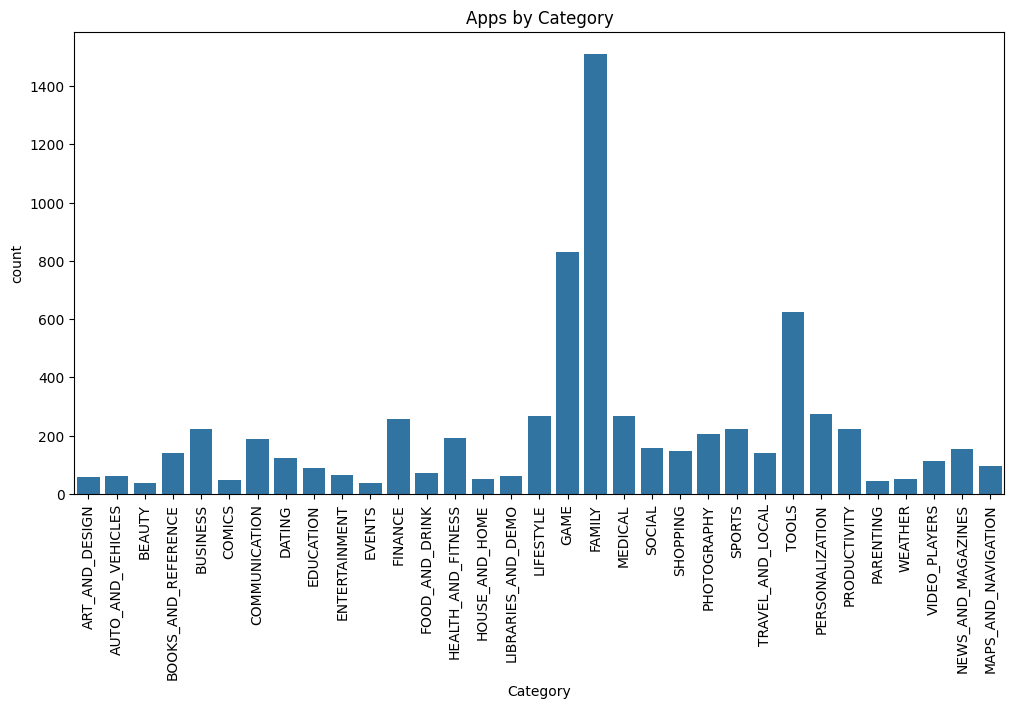

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

sns.countplot(x="Category", data=df)

plt.xticks(rotation=90)

plt.title("Apps by Category")

plt.show()

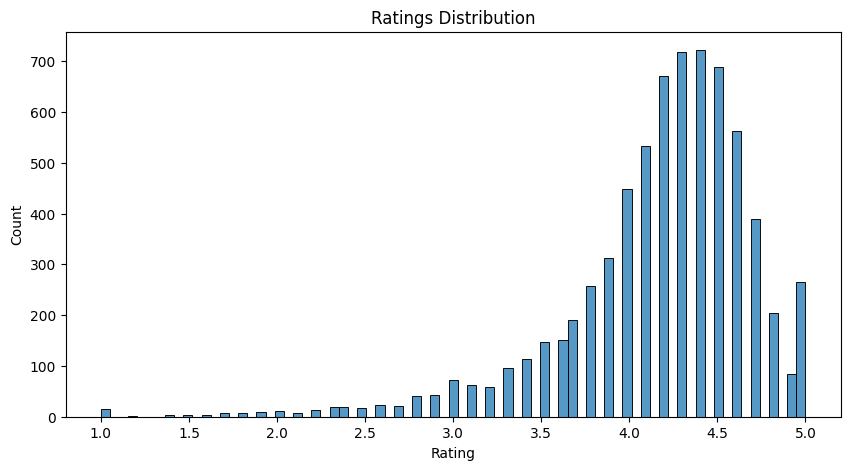

In [17]:
plt.figure(figsize=(10,5))

sns.histplot(df["Rating"])

plt.title("Ratings Distribution")

plt.show()

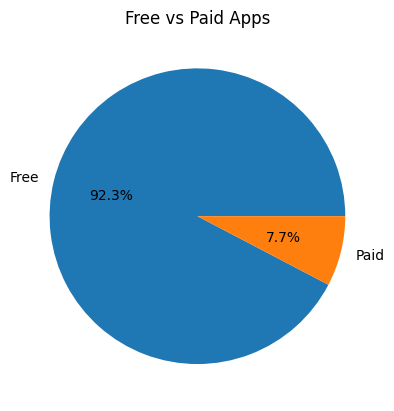

In [18]:
df["Type"].value_counts().plot.pie(autopct="%1.1f%%")

plt.ylabel("")

plt.title("Free vs Paid Apps")

plt.show()

In [20]:
df["Installs"] = df["Installs"].str.replace(",", "")
df["Installs"] = df["Installs"].str.replace("+", "", regex=False)

df["Installs"] = pd.to_numeric(df["Installs"])

df[["App", "Installs"]].sort_values(by="Installs", ascending=False).head(10)

,App,Installs
2977,Google News,1000000000
1356,Subway Surfers,1000000000
2527,SHAREit - Transfer & Share,500000000
1364,Pou,500000000
1363,Temple Run 2,500000000
2739,Dropbox,500000000
311,imo free video calls and chat,500000000
342,UC Browser - Fast Download Private & Secure,500000000
1357,Candy Crush Saga,500000000
4623,Samsung Health,500000000


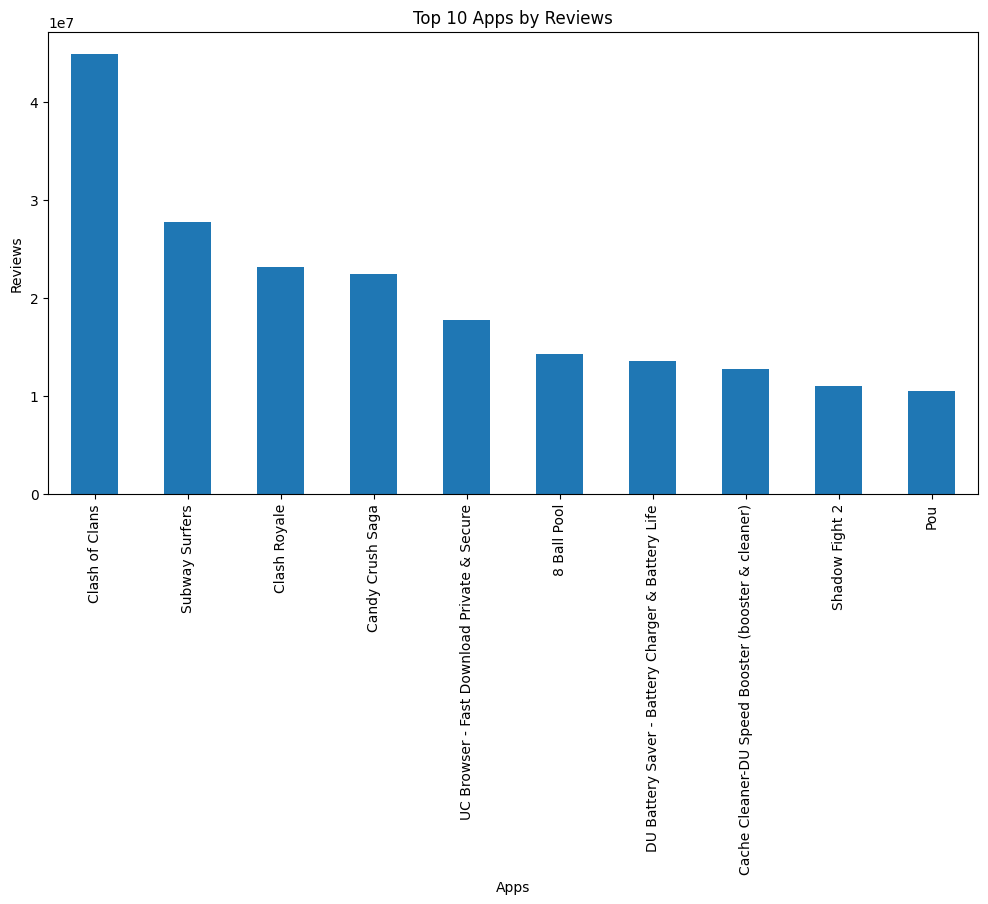

In [24]:
top_apps = df.groupby("App")["Reviews"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
top_apps.plot(kind="bar")

plt.title("Top 10 Apps by Reviews")
plt.xlabel("Apps")
plt.ylabel("Reviews")

plt.show()

In [25]:
df.to_csv("Google_Play_Store_Cleaned.csv", index=False)

print("Dataset saved successfully!")

Dataset saved successfully!
